# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

plt.style.use("ggplot")

# Load Data

In [3]:
fake_df = pd.read_csv("../data/raw/Fake.csv")
real_df = pd.read_csv("../data/raw/True.csv")

fake_df["label"] = 1
real_df["label"] = 0

df = pd.concat([fake_df, real_df], ignore_index=True)

df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


# Basic Info

In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62638 entries, 0 to 62637
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   62160 non-null  object
 1   text    62638 non-null  object
 2   label   62638 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


title    478
text       0
label      0
dtype: int64

# Class Distribution

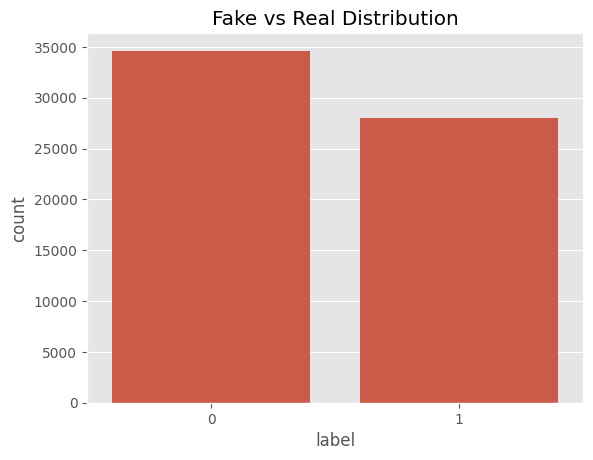

In [5]:
sns.countplot(data=df, x="label")
plt.title("Fake vs Real Distribution")
plt.show()

# Text Length Analysis

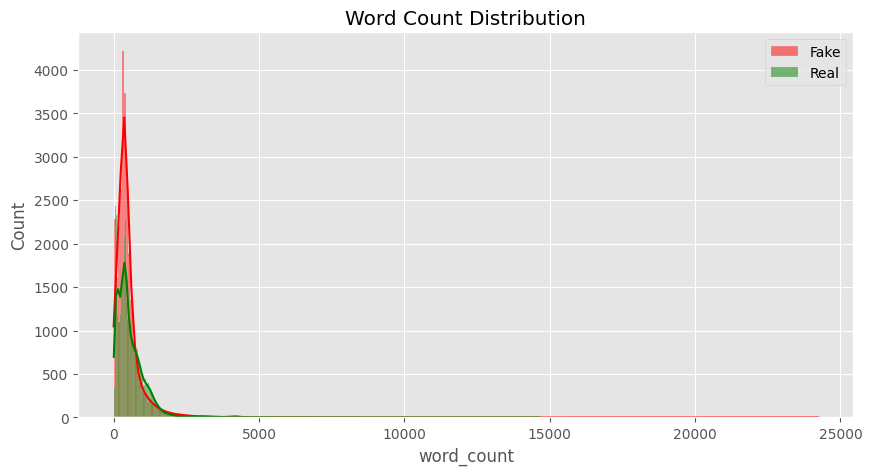

In [7]:
df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df[["text_length", "word_count"]].describe()


plt.figure(figsize=(10,5))
sns.histplot(df[df["label"]==1]["word_count"], color="red", label="Fake", kde=True)
sns.histplot(df[df["label"]==0]["word_count"], color="green", label="Real", kde=True)
plt.legend()
plt.title("Word Count Distribution")
plt.show()

# Title vs Label Insight

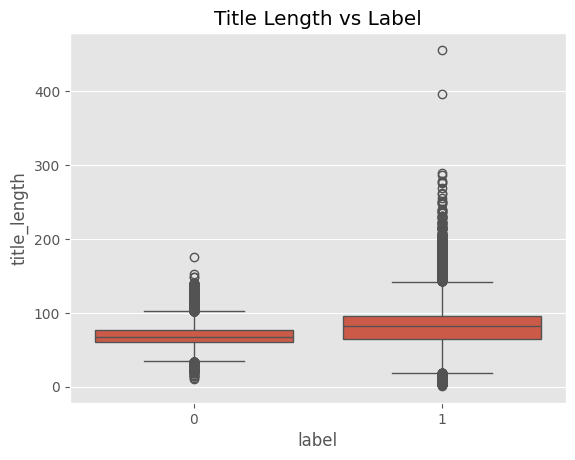

In [8]:
df["title_length"] = df["title"].astype(str).apply(len)

sns.boxplot(x="label", y="title_length", data=df)
plt.title("Title Length vs Label")
plt.show()

# Most Common Words (Fake)

In [9]:
fake_words = " ".join(df[df["label"]==1]["text"].astype(str)).lower()
fake_words = re.findall(r"\b[a-z]{3,}\b", fake_words)

Counter(fake_words).most_common(20)

[('the', 793032),
 ('and', 341293),
 ('that', 212057),
 ('for', 130340),
 ('with', 90045),
 ('trump', 89422),
 ('was', 84733),
 ('this', 84372),
 ('are', 76033),
 ('have', 68522),
 ('his', 66681),
 ('they', 66318),
 ('not', 65807),
 ('you', 64467),
 ('has', 60266),
 ('from', 59040),
 ('who', 51819),
 ('but', 50558),
 ('their', 43841),
 ('about', 42536)]

# Most Common Words (Real)

In [10]:
real_words = " ".join(df[df["label"]==0]["text"].astype(str)).lower()
real_words = re.findall(r"\b[a-z]{3,}\b", real_words)

Counter(real_words).most_common(20)

[('the', 1178752),
 ('and', 462524),
 ('that', 257886),
 ('for', 192516),
 ('said', 183293),
 ('with', 132873),
 ('was', 131918),
 ('trump', 106495),
 ('his', 104668),
 ('has', 97018),
 ('from', 90954),
 ('have', 90407),
 ('not', 88561),
 ('but', 79792),
 ('who', 75727),
 ('are', 73558),
 ('they', 69277),
 ('had', 65617),
 ('this', 64010),
 ('would', 62073)]

# Fake vs Real Word Comparison Plot

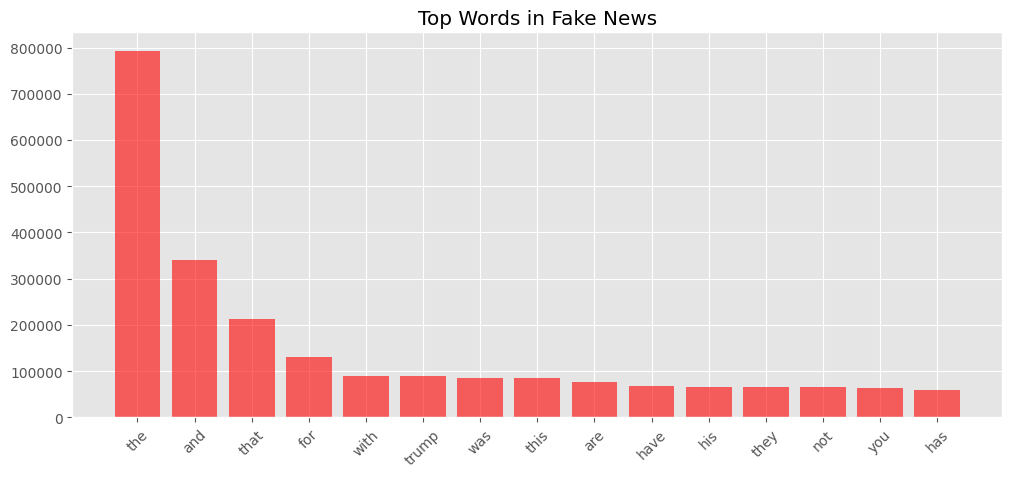

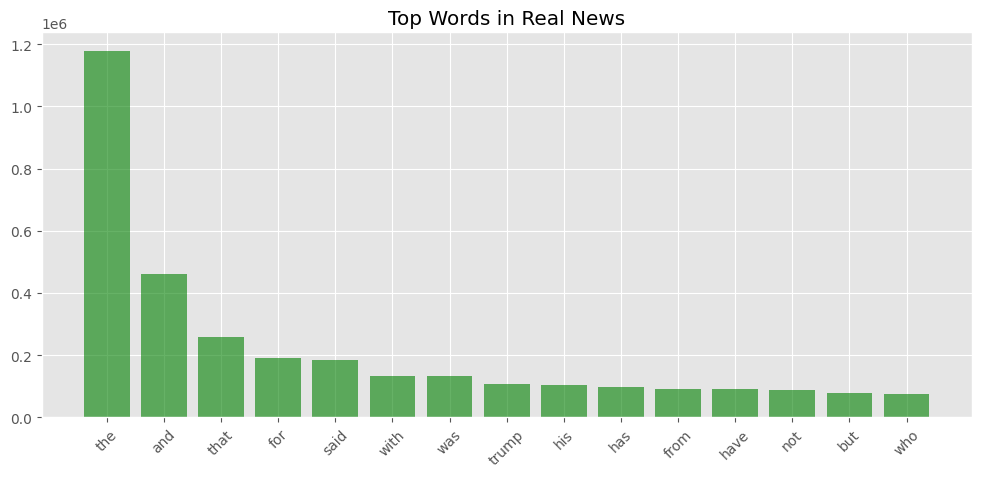

In [11]:
fake_top = dict(Counter(fake_words).most_common(15))
real_top = dict(Counter(real_words).most_common(15))

plt.figure(figsize=(12,5))
plt.bar(fake_top.keys(), fake_top.values(), color="red", alpha=0.6)
plt.title("Top Words in Fake News")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,5))
plt.bar(real_top.keys(), real_top.values(), color="green", alpha=0.6)
plt.title("Top Words in Real News")
plt.xticks(rotation=45)
plt.show()

# Insight Summary

In [12]:
print("Dataset Summary:")
print(f"Fake articles: {len(df[df['label']==1])}")
print(f"Real articles: {len(df[df['label']==0])}")
print(f"Avg words (Fake): {df[df['label']==1]['word_count'].mean():.2f}")
print(f"Avg words (Real): {df[df['label']==0]['word_count'].mean():.2f}")

Dataset Summary:
Fake articles: 28020
Real articles: 34618
Avg words (Fake): 511.02
Avg words (Real): 580.97
